In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data_train = pd.read_csv("feature-engineering-train.csv")
data_test = pd.read_csv("feature-engineering-test.csv")

X_train, y_train = data_train.drop(columns=["label"]), data_train["label"]
X_test, y_test = data_test.drop(columns=["label"]), data_test["label"]

X = pd.concat((X_train, X_test), axis=0)
y = pd.concat((y_train, y_test), axis=0)

In [3]:
from functools import reduce

binary_columns = [col for col in X.columns if col.startswith("B")]
discrete_columns = [col for col in X.columns if col.startswith("D")]
float_columns = [col for col in X.columns if col.startswith("F")]
object_columns = [col for col in X.columns if col.startswith("O")]

columns = reduce(
    np.union1d,
    (
        binary_columns,
        discrete_columns,
        float_columns,
        object_columns,
    ),
)
np.setdiff1d(X.columns, columns)

array([], dtype=object)

In [4]:
X = X.drop(columns=object_columns)
X_train = X_train.drop(columns=object_columns)
X_test = X_test.drop(columns=object_columns)

# 1. Feature Selection

## 1.1. Mutual Information for Binary features

In [5]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(X_train, y_train)
mi = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)
mi

DLineOfCode                 0.591292
DNoOfImage                  0.533743
DNoOfExternalRef            0.531176
DNoOfSelfRef                0.511920
DNoOfJS                     0.496211
DLargestLineLength          0.490551
DNoOfCSS                    0.443458
BHasSocialNet               0.389678
BHasCopyrightInfo           0.327287
BHasDescription             0.287472
BHasSubmitButton            0.193840
FTLD                        0.171322
DNoOfEmptyRef               0.170998
DNoOfiFrame                 0.169725
BIsResponsive               0.166449
BIsHTTPS                    0.161476
FDomainEntropy              0.153199
BHasHiddenFields            0.145803
BHasDomainTitleMatch        0.145437
BHasFavicon                 0.143671
FURLCharProb                0.138332
BHasTitle                   0.125859
FAlphabetRatioInDomain      0.123161
BHasURLTitleMatch           0.119987
DNoOfDigitsInDomain         0.100492
DNoOfTokensInDomain         0.099177
DDomainLength               0.088128
B

In [6]:
select_binary_columns = [col for col in mi.index if col.startswith("B")][:4]
select_binary_columns

['BHasSocialNet', 'BHasCopyrightInfo', 'BHasDescription', 'BHasSubmitButton']

Based on the results of MI regression, the most important binary features are

- `HasSocialNet`
- `HasCopyrightInfo`
- `HasDescription`
- `HasSubmitButton`

## 1.2. Anova for floating point features

**Note:** We need to check for normality to apply ANOVA.

In [7]:
from sklearn.feature_selection import f_classif

F, pvals = f_classif(X[float_columns], y.values)

pd.DataFrame(
    {
        "feature": float_columns,
        "F": F,
        "pval": pvals,
    }
).sort_values("pval")

,feature,F,pval
0,FTLD,89186.923651,0.0
1,FURLCharProb,64607.226549,0.0
2,FAlphabetRatioInDomain,19142.071368,0.0
3,FDomainEntropy,18619.369205,0.0


All of the columns have very low p-values (nearly zero). So, we keep all of the floating point columns.

## 1.3. Wrapper Method: RFE

**Note:** Takes too long.

In [8]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
rfe = RFE(model, step=1)
rfe.fit(X_train, y_train)
pd.Series(rfe.ranking_, index=X_train.columns).sort_values(ascending=True)

/Users/akkus/Documents/GitHub/Phishing-URL--Website--Detection/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/akkus/Documents/GitHub/Phishing-URL--Website--Detection/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also

BHasSubmitButton             1
BHasPasswordField            1
BHasCopyrightInfo            1
DNoOfPopup                   1
BHasDescription              1
DNoOfDigitsInDomain          1
BHasURLRedirect              1
DNoOfHyphensInDomain         1
FAlphabetRatioInDomain       1
BHasFavicon                  1
BHasSocialNet                1
BHasTitle                    1
BHasDomainTitleMatch         1
BIsHTTPS                     1
DNoOfObfuscatedChar          1
BHasObfuscation              1
DNoOfSubDomain               1
DTLDLength                   1
FURLCharProb                 1
FTLD                         1
BIsDomainIP                  1
BHasCharContinuation         1
BHasHiddenFields             1
BHasURLTitleMatch            2
BHasHyphenInDomain           3
BBank                        4
DNoOfImage                   5
FDomainEntropy               6
DNoOfSelfRef                 7
BRobots                      8
DNoOfJS                      9
BHasExternalFormSubmit      10
DNoOfTok

In [9]:
X_train.columns[rfe.get_support()]

Index(['BIsDomainIP', 'FTLD', 'FURLCharProb', 'DTLDLength', 'DNoOfSubDomain',
       'BHasObfuscation', 'DNoOfObfuscatedChar', 'BIsHTTPS', 'BHasTitle',
       'BHasFavicon', 'BHasURLRedirect', 'BHasDescription', 'DNoOfPopup',
       'BHasSocialNet', 'BHasSubmitButton', 'BHasHiddenFields',
       'BHasPasswordField', 'BHasCopyrightInfo', 'DNoOfDigitsInDomain',
       'DNoOfHyphensInDomain', 'FAlphabetRatioInDomain',
       'BHasCharContinuation', 'BHasDomainTitleMatch'],
      dtype='object')

## 1.4. Embedded Method: Random Forest

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_jobs=-1, random_state=0)
rf.fit(X_train, y_train)
importances = pd.Series(
    data=rf.feature_importances_,
    index=X_train.columns,
).sort_values()

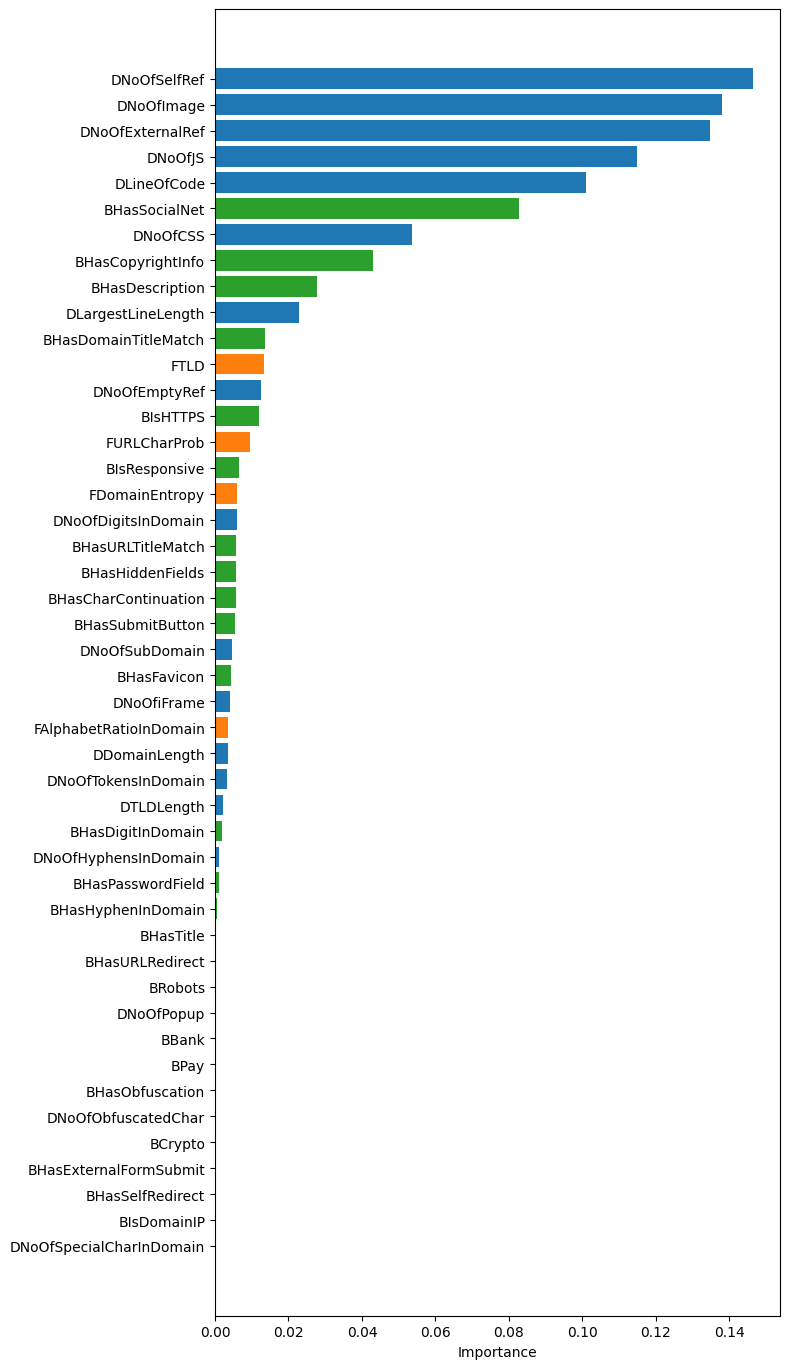

In [11]:
def feature_color(name):
    if name.startswith("D"):
        return "tab:blue"
    if name.startswith("F"):
        return "tab:orange"
    if name.startswith("B"):
        return "tab:green"
    return "gray"


plt.figure(figsize=(8, 0.3 * len(importances)))
plt.barh(
    importances.index,
    importances.values,
    color=[feature_color(f) for f in importances.index]
)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 1.5. L1-Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from joblib import Parallel, delayed

Cs = [1.0, 0.5, 0.1, 0.05, 0.01]


def fit_model(C):
    pipe = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    penalty="l1",
                    solver="liblinear",
                    C=C,
                    max_iter=500,
                    random_state=0,
                ),
            ),
        ]
    )
    pipe.fit(X_train, y_train)
    return pipe


models = Parallel(n_jobs=-1, backend="loky")(delayed(fit_model)(C) for C in Cs)
models = dict(zip(Cs, models))

/Users/akkus/Documents/GitHub/Phishing-URL--Website--Detection/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/akkus/Documents/GitHub/Phishing-URL--Website--Detection/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/akkus/Documents/GitHub/Phishing-URL--Website--Detection/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/akkus/Documents/GitHub/Phishing-URL--Website--Detection/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [13]:
for C, model in models.items():
    coefs = model.named_steps["clf"].coef_.ravel()
    print(f"{C}: {coefs}")

1.0: [-2.47067437e-01 -1.00474199e+01  1.00108366e+00  9.44415716e-01
 -1.07567898e+00  6.39218664e-01 -4.51617874e-01 -4.43242871e+00
  1.87733459e+00  1.56105870e+00 -8.31053894e+00  1.10327924e+00
  2.64736741e-01 -2.93032700e-02  1.08085557e-01 -2.58911210e-01
 -5.14277842e-02  8.06088988e-01  3.30929308e-01 -4.97575629e-02
 -4.61384706e-03  1.25216882e+00  2.98518728e-01  2.36647285e-01
 -4.32667594e-01 -9.05400099e-02  1.81233346e-01 -1.16016527e-02
  9.17342437e-01  1.99879519e+00  8.37924031e-01  2.08294613e+00
  2.35074441e+00 -5.50317362e-02  1.54695832e+00 -1.34422746e+00
 -1.71013130e-01 -4.02884602e-02 -6.76814590e-01  1.78743758e-01
  1.75784562e-02  5.27708573e-01  9.70631322e-02  1.02803825e+00
 -1.35052949e-01  3.22383717e-01]
0.5: [-2.39856349e-01 -9.04891568e+00  1.02526761e+00  9.22906350e-01
 -1.12412461e+00  6.36297174e-01 -6.17575610e-01 -2.77849568e+00
  1.89993544e+00  1.71640056e+00 -8.81271201e+00  1.24328132e+00
  2.71667410e-01 -7.62468134e-03  1.22796880e-

In [14]:
pd.Series(
    data=models[0.01].named_steps["clf"].coef_.ravel(),
    index=X_train.columns,
).abs().sort_values(ascending=True)

DNoOfEmptyRef               0.000000
DNoOfiFrame                 0.000000
DNoOfPopup                  0.000000
BHasSelfRedirect            0.000000
BRobots                     0.000000
BCrypto                     0.000000
BHasExternalFormSubmit      0.000000
DNoOfSpecialCharInDomain    0.000000
BHasHyphenInDomain          0.000000
FDomainEntropy              0.000000
BIsDomainIP                 0.000000
DNoOfObfuscatedChar         0.000000
BPay                        0.016984
BBank                       0.023621
BIsResponsive               0.038701
DNoOfTokensInDomain         0.072660
BHasObfuscation             0.079503
BHasDigitInDomain           0.105615
BHasURLRedirect             0.150104
DNoOfHyphensInDomain        0.155957
BHasURLTitleMatch           0.171658
FAlphabetRatioInDomain      0.178626
BHasSubmitButton            0.181716
BHasHiddenFields            0.200465
BHasFavicon                 0.220609
DDomainLength               0.259809
BHasPasswordField           0.268160
D

# 2. Scale and Check Variables

## 2.1. Scale variables

In [15]:
from sklearn.preprocessing import StandardScaler



# 3. Model Assumptions

## 3.1. Linearity of Logit

In [16]:
import statsmodels.api as sm

X_bt = X.copy()

for c in float_columns:
    X_bt[f"{c}_log"] = X[c] * np.log(X[c].clip(lower=1e-6))

X_bt = sm.add_constant(X_bt)
model = sm.Logit(y, X_bt).fit(disp=0)

bt_terms = [c for c in X_bt.columns if c.endswith("_log")]
model.pvalues[bt_terms]

/Users/akkus/Documents/GitHub/Phishing-URL--Website--Detection/.venv/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/akkus/Documents/GitHub/Phishing-URL--Website--Detection/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


FTLD_log                      2.835285e-02
FURLCharProb_log              8.946598e-01
FAlphabetRatioInDomain_log    3.073186e-26
FDomainEntropy_log            8.121489e-31
dtype: float64

In [17]:
model.pvalues[bt_terms] < 0.05

FTLD_log                       True
FURLCharProb_log              False
FAlphabetRatioInDomain_log     True
FDomainEntropy_log             True
dtype: bool

All p-values are significant ($\alpha = 0.05$), except for `URLCharProb`.

## 3.2. No Perfect Multicollinearity

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_ = X.drop(columns=["FAlphabetRatioInDomain"])

X_vif = sm.add_constant(X_)

vif = pd.Series(
    [variance_inflation_factor(X_vif.values, i)
     for i in range(1, X_vif.shape[1])],
    index=X_.columns
)

vif.sort_values(ascending=False)

DNoOfHyphensInDomain        4.572469
DDomainLength               4.148537
BHasDomainTitleMatch        4.055206
BHasURLTitleMatch           3.989590
DNoOfTokensInDomain         3.617471
BHasHyphenInDomain          3.270653
FDomainEntropy              3.259636
DNoOfDigitsInDomain         2.540251
BHasSocialNet               2.489059
BHasCharContinuation        2.475879
DNoOfSelfRef                2.274784
DNoOfSubDomain              2.216935
BHasCopyrightInfo           2.185245
DNoOfExternalRef            2.063275
BHasDigitInDomain           2.031859
BHasSubmitButton            1.980220
BHasDescription             1.940785
FURLCharProb                1.884786
BIsHTTPS                    1.818069
BIsResponsive               1.792139
BHasHiddenFields            1.740538
BHasTitle                   1.531219
BHasSelfRedirect            1.451481
FTLD                        1.451353
DTLDLength                  1.442969
BHasFavicon                 1.419775
BHasURLRedirect             1.418080
D

We have some problematic columns:
- `FAlphabetRatioInDomain`
- `DNoOfDigitsInDomain`
- `DDomainLength`

All of these features and some other features related to domain have high VIF.

# 4. Transformation

Apply Box-Cox to strictly positive variables and Yeo-Johnson to the rest.

In [19]:
numeric_columns = np.union1d(discrete_columns, float_columns)

q = (X_train[numeric_columns] <= 0).sum() == 0
box_cox_columns = q[q].index
yeo_johnson_columns = q[~q].index

In [20]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="box-cox", standardize=True)

pt.fit(X_train[box_cox_columns])

X_train[box_cox_columns] = pd.DataFrame(pt.transform(X_train[box_cox_columns]), columns=box_cox_columns, index=X_train.index)
X_test[box_cox_columns] = pd.DataFrame(pt.transform(X_test[box_cox_columns]), columns=box_cox_columns, index=X_test.index)

pt = PowerTransformer(method="yeo-johnson", standardize=True)

pt.fit(X_train[yeo_johnson_columns])

X_train[yeo_johnson_columns] = pd.DataFrame(pt.transform(X_train[yeo_johnson_columns]), columns=yeo_johnson_columns, index=X_train.index)
X_test[yeo_johnson_columns] = pd.DataFrame(pt.transform(X_test[yeo_johnson_columns]), columns=yeo_johnson_columns, index=X_test.index)

In [28]:
#we need to combine X_train and y_train to save the transformed files
train_transformed = pd.concat([X_train, y_train], axis=1)
test_transformed = pd.concat([X_test, y_test], axis=1)
train_transformed.to_csv("feature-engineering-transform-train.csv", index=False)
test_transformed.to_csv("feature-engineering-transform-test.csv", index=False)

# 5. PCA

In [30]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_train_ = X_train.select_dtypes(exclude=["object"])

X_train_scaled = StandardScaler().fit_transform(X_train_)
pca = PCA(random_state=0)
X_train_pca = pca.fit_transform(X_train_scaled)
#we will save the file for PCA transformed data
#we need to dimencion reduction to explain 85% variance
explained_variance = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(explained_variance >= 0.85) + 1
n_components
pca = PCA(n_components=n_components, random_state=0)
X_train_pca = pca.fit_transform(X_train_scaled)
#we need to combine X_train and y_train to save the transformed files
train_pca = pd.concat([pd.DataFrame(X_train_pca), y_train.reset_index(drop=True)], axis=1)
train_pca.to_csv("feature-engineering-pca-train.csv", index=False)
# we need to apply to test data as well we need to apply standard scaling to binary columns only bc we already apply rest of it
X_test_ = X_test.select_dtypes(exclude=["object"])
# we need to apply to binary columns only bc we already apply rest of it
X_test_scaled = StandardScaler().fit_transform(X_test_)
X_test_pca = pca.transform(X_test_scaled)
# combine X_test and y_test to save the transformed files
test_pca = pd.concat([pd.DataFrame(X_test_pca), y_test.reset_index(drop=True)], axis=1)
test_pca.to_csv("feature-engineering-pca-test.csv", index=False)

In [23]:
pca.explained_variance_ratio_

array([0.27545572, 0.08131098, 0.04648434, 0.04309698, 0.03790952,
       0.03714822, 0.03411467, 0.03006261, 0.02633389, 0.02335592,
       0.0223776 , 0.0216925 , 0.0213453 , 0.02046113, 0.01974692,
       0.01818171, 0.01779043, 0.01618408, 0.01530956, 0.01495805,
       0.01414179, 0.01353304, 0.01315315, 0.01277603, 0.0120961 ,
       0.01087047, 0.01066631, 0.00986982, 0.00870057, 0.0086344 ,
       0.00834813, 0.00818841, 0.00744201, 0.00648084, 0.00548986,
       0.0051739 , 0.00351121, 0.00306873, 0.00266444, 0.00256017,
       0.00235296, 0.00222979, 0.0021438 , 0.00132798, 0.00066267,
       0.00059333])

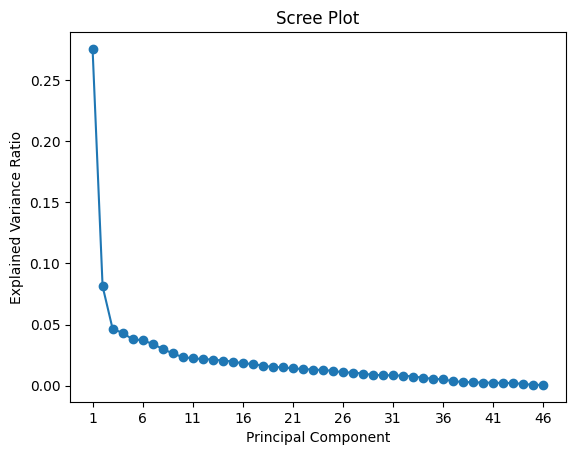

In [24]:
evr = pca.explained_variance_ratio_
n = len(evr)

plt.figure()
plt.plot(np.arange(1, n + 1), evr, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(np.arange(1, n + 1, 5))
plt.show()

# t-SNE and UMAP

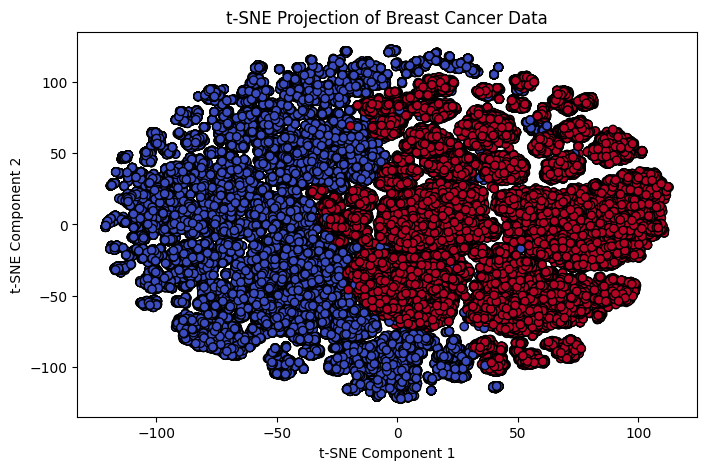

In [25]:
from sklearn.manifold import TSNE # Import the TSNE class

X_train_ = X_train.select_dtypes(exclude=["object"])

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_train_)

plt.figure(figsize=(8, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train, cmap='coolwarm', edgecolors='k')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE Projection of Breast Cancer Data')
plt.show()

In [ ]:
from sklearn.manifold import TSNE # Import the TSNE class

idx = np.random.choice(X_train.index, size=round(0.2 * len(X_train)), replace=False)
X_train_ = X_train.loc[idx].select_dtypes(exclude=["object"])
y_train_ = y_train.loc[idx]


def run_tsne(perp, X, y):
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        init="pca",
        #learning_rate=200,
        random_state=42,
    )
    X_tsne = tsne.fit_transform(X)

    plt.figure(figsize=(8, 5))
    plt.scatter(
        X_tsne[:, 0],
        X_tsne[:, 1],
        c=y,
        cmap="coolwarm",
        edgecolors="k",
    )
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.title(f"t-SNE Projection (Perplexity={perp})")
    plt.show()


perplexities = [5, 10, 20, 30, 50]

Parallel(n_jobs=-1)(
    delayed(run_tsne)(perp, X_train_, y_train_)
    for perp in perplexities
)

Figure(800x500)
Figure(800x500)
Figure(800x500)
Figure(800x500)
Figure(800x500)


[None, None, None, None, None]